# Mining and gAmblinG servIces sCrapIng and ANalysis #

**Data:** 16/01/2026  
**Autore:** Pierpaolo Fioretto

## Introduzione

Questo notebook presenta un’analisi delle transazioni Bitcoin finalizzata allo studio del comportamento di due tipologie di servizi operanti sulla blockchain:

- **Deepbit.net**: una mining pool, che aggrega la potenza computazionale di numerosi miner e redistribuisce le ricompense dei blocchi minati
- **DiceOnCrack**: un servizio di gambling che permette il pagamento tramite criptovalute, caratterizzato da transazioni ripetitive e temporalmente ravvicinate riconducibili a singoli utenti

L’obiettivo è identificare, all’interno di un dataset di transazioni Bitcoin, i flussi di pagamento associati a tali servizi e analizzarne le caratteristiche strutturali e temporali.

---

## Dataset e modello di riferimento

Il dataset utilizzato descrive le transazioni Bitcoin secondo il modello **UTXO (Unspent Transaction Output)**, in cui:

- ogni **output** rappresenta una quantità di bitcoin assegnata a un indirizzo
- ogni **input** spende un output precedente
- una transazione è definita come coinbase se crea nuovi bitcoin e ricompensa il miner che ha prodotto il blocco

I file forniti contengono informazioni sulle transazioni, sugli input e sugli output, oltre a una mappatura tra hash degli indirizzi Bitcoin e identificativi numerici (`addressId`).

---

## Identificazione dei servizi tramite WalletExplorer

Gli indirizzi associati ai servizi analizzati sono stati ottenuti tramite scraping dal sito **WalletExplorer**, che utilizza euristiche di clustering basate sul comportamento delle transazioni per raggruppare indirizzi probabilmente controllati dalla stessa entità.
Tali indirizzi non rappresentano un insieme esaustivo né ufficiale, ma una stima affidabile del wallet logico del servizio.

---

## Struttura dell’analisi

Il notebook è organizzato come segue:

1) Scraping degli indirizzi associati a Deepbit.net e DiceOnCrack
2) Individuazione delle transazioni associate a Deepbit.net
3) Identificazione delle coinbase di Deepbit.net
4) Distribuzione temporale dei blocchi minati da Deepbit.net
5) Distribuzione delle fee ricevute dalla mining pool Deepbit.net
6) Calcolo degli UTXO cumulativi associati a Deepbit.net
7) Costruzione e analisi della catena di pagamenti Deepbit.net
8) Analisi delle differenze temporali nella catena di pagamenti
9) Analisi del servizio di gambling DiceOnCrack

In [1]:
# ===============================
# Scraping degli address Bitcoin da i wallet "Deepbit.net" e "DiceOnCrack"
# ===============================

import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.common.exceptions import NoSuchElementException

options = Options()
options.binary_location = "/usr/bin/chromium-browser"
#options.add_argument("--headless=new")
options.add_argument("--no-sandbox") 
options.add_argument("--disable-dev-shm-usage")
options.add_argument(
    "user-agent=Mozilla/5.0 (X11; Linux x86_64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) " 
    "Chrome/120.0.0.0 Safari/537.36"
)

service = Service("/usr/bin/chromedriver")                  # Percorso del chromedriver
driver = webdriver.Chrome(service=service, options=options) # Inizializzazione del driver

# Funzione di scraping
def scrape_wallet_addresses(driver, wallet_name, max_pages=100):
    print(f"\n=== Scraping wallet: {wallet_name} ===")

    base_url = f"https://www.walletexplorer.com/wallet/{wallet_name}"
    driver.get(base_url)
    time.sleep(2)

    # clic su "show wallet addresses"
    show_addr = driver.find_element(By.LINK_TEXT, "show wallet addresses")
    show_addr.click()
    time.sleep(2)

    addresses = set()
    page = 0

    while page < max_pages:
        page += 1
        print(f"Scraping pagina {page}")

        rows = driver.find_elements(By.XPATH, "//table//tr") # trova tutte le righe della tabella

        found = 0
        for row in rows[1:]:  # skip header
            cols = row.find_elements(By.TAG_NAME, "td") # trova tutte le colonne della riga
            if cols:
                addr = cols[0].text.strip() # prima colonna è l'indirizzo
                if addr.startswith(("1", "3")): #indirizzi Bitcoin
                    addresses.add(addr)
                    found += 1

        print("Indirizzi trovati in questa pagina:", found)
        print("Totale indirizzi finora:", len(addresses))

        # paginazione e terminazione
        current_url = driver.current_url
        try:
            next_link = driver.find_element(By.PARTIAL_LINK_TEXT, "Next")
            next_link.click()
            time.sleep(4)

            if driver.current_url == current_url:  # se non cambia URL, siamo alla fine
                break
        except NoSuchElementException:
            break

        if found == 0:
            break

    return addresses

# Scraping Deepbit.net
deepbit_addrs = scrape_wallet_addresses(driver, "Deepbit.net", max_pages=20)
print("\nTOTALE Deepbit:", len(deepbit_addrs))

# Scraping DiceOnCrack
dice_addrs = scrape_wallet_addresses(driver, "DiceOnCrack", max_pages=20)
print("\nTOTALE DiceOnCrack:", len(dice_addrs))

# Salvataggio risultati
pd.Series(sorted(deepbit_addrs)).to_csv("deepbit_addrs.csv", index=False)
pd.Series(sorted(dice_addrs)).to_csv("diceoncrack_addrs.csv", index=False)

# Chiusura del driver
driver.quit()



=== Scraping wallet: Deepbit.net ===
Scraping pagina 1
Indirizzi trovati in questa pagina: 2
Totale indirizzi finora: 2

TOTALE Deepbit: 2

=== Scraping wallet: DiceOnCrack ===
Scraping pagina 1
Indirizzi trovati in questa pagina: 28
Totale indirizzi finora: 28

TOTALE DiceOnCrack: 28



---

## Individuazione delle transazioni associate a Deepbit.net

In questa sezione vengono identificate tutte le transazioni del dataset riconducibili alla mining pool **Deepbit.net**.  
Una transazione è considerata associata al servizio se presenta **almeno un indirizzo di input o di output appartenente a Deepbit**.

Gli indirizzi di Deepbit, ottenuti tramite scraping da WalletExplorer, vengono mappati sugli `addressId` del dataset.  
A partire da questi, si individuano:
- le transazioni che **inviano fondi a Deepbit** (output);
- le transazioni che **spendono fondi precedentemente appartenenti a Deepbit** (input).

L’unione di questi due insiemi fornisce l’insieme completo delle **transazioni coinvolgenti la mining pool**.


In [2]:
# ===============================
# Caricamento dataset
# ===============================

transactions = pd.read_csv("transactions.csv", header=None, names=["timestamp", "blockId", "txId", "isCoinbase", "fee"])
inputs = pd.read_csv("inputs.csv", header=None, names=["txId", "prevTxId", "prevTxpos"])
outputs = pd.read_csv("outputs.csv", header=None, names=["txId", "position", "address", "amount", "scripttype"])
mapping = pd.read_csv("mapping.csv", header=None, names=["hash", "addressId"])
deepbit_addrs = pd.read_csv("deepbit_addrs.csv", header=None, names=["hash"])

# ===============================
# Mapping hash -> addressId
# ===============================

#join tra campo hash di mapping e deepbit_addrs
deepbit_address_ids = mapping.merge(deepbit_addrs, on="hash", how="inner")["addressId"].unique()

print("AddressId Deepbit:", deepbit_address_ids)

# ===============================
# OUTPUT verso Deepbit
# ===============================

deepbit_outputs = outputs[
    outputs["address"].isin(deepbit_address_ids) #isin controlla se gli addressId di deepbit_address_ids sono in outputs
]

tx_out_deepbit = deepbit_outputs["txId"].unique()
print("Transazioni con output Deepbit:", len(tx_out_deepbit))

# ===============================
# INPUT da Deepbit
# ===============================

deepbit_utxo = deepbit_outputs[["txId", "position"]]

#join tra campo prevTxId e prevTxpos di inputs e txId e txid e position di deepbit_utxo
deepbit_inputs = inputs.merge(deepbit_utxo, left_on=["prevTxId", "prevTxpos"], right_on=["txId", "position"], how="inner") 
tx_in_deepbit = deepbit_inputs["txId_x"].unique()
print("Transazioni con input Deepbit:", len(tx_in_deepbit))

# ===============================
# Tutte le transazioni Deepbit
# ===============================

deepbit_tx_ids = set(tx_out_deepbit) | set(tx_in_deepbit) # Unione degli insiemi, contiene solo ids
print("Totale transazioni Deepbit:", len(deepbit_tx_ids))

deepbit_transactions = transactions[  # Filtra le transazioni che coinvolgono Deepbit, contiene tutte le info
    transactions["txId"].isin(deepbit_tx_ids)
]


AddressId Deepbit: [2536929 2537090]
Transazioni con output Deepbit: 605388
Transazioni con input Deepbit: 596034
Totale transazioni Deepbit: 608699


## Individuazione delle coinbase associate a Deepbit.net

In questa sezione viene ricostruito il pattern di ricezione delle ricompense e delle fee adottato dalla mining pool Deepbit.net, al fine di individuare le coinbase riconducibili ai blocchi minati dal servizio, anche quando la ricompensa non viene trasferita direttamente a un indirizzo Deepbit.

L’analisi parte dalla selezione di tutte le transazioni coinbase del dataset e dei relativi output, che rappresentano la creazione iniziale dei bitcoin. Vengono quindi individuate le transazioni che spendono direttamente output di coinbase e, tra queste, quelle che trasferiscono fondi verso indirizzi associati a Deepbit.net.

Risalendo dalle transazioni che pagano Deepbit agli output di coinbase originari, è possibile identificare l’insieme delle coinbase effettivamente associate alla mining pool.

In [3]:
# =========================================================
# INDIVIDUAZIONE COINBASE ASSOCIATE A DEEPBIT
# =========================================================

# =========================================================
# 1. Selezione di tutte le transazioni coinbase
# =========================================================

coinbase_tx = transactions[
    transactions["isCoinbase"] == 1
][["txId", "blockId", "timestamp"]]

print("Coinbase totali nel dataset:", len(coinbase_tx))

# =========================================================
# 2. Estrazione degli output delle coinbase
# =========================================================

#join tra campo txId di outputs e campo txId di coinbase_tx
coinbase_outputs = outputs.merge(coinbase_tx[["txId"]], on="txId", how="inner")[["txId", "position"]] #per trovare chi stanno pagando le coinbase

print("Output delle coinbase:", len(coinbase_outputs))

# =========================================================
# 3. Transazioni che spendono output di coinbase
# =========================================================

#join tra campo prevTxId e prevTxpos di inputs e txId e position di coinbase_outputs
spend_coinbase = inputs.merge(coinbase_outputs, left_on=["prevTxId", "prevTxpos"], right_on=["txId", "position"], how="inner")

print("Transazioni che spendono coinbase:", spend_coinbase["txId_x"].nunique())

# =========================================================
# 4. Output delle transazioni che spendono coinbase
# =========================================================

spend_tx_ids = spend_coinbase["txId_x"].unique()

spend_outputs = outputs[
    outputs["txId"].isin(spend_tx_ids)
]

# =========================================================
# 5. Selezione degli output che pagano Deepbit
# =========================================================

deepbit_spend = spend_outputs[
    spend_outputs["address"].isin(deepbit_address_ids) 
]

print("Transazioni che pagano Deepbit:",deepbit_spend["txId"].nunique())

# =========================================================
# 6. Risalita alle coinbase originali Deepbit
# =========================================================

#join tra campo txId_x di spend_coinbase e campo txId di deepbit_spend
deepbit_coinbase = spend_coinbase.merge(deepbit_spend[["txId"]], left_on="txId_x", right_on="txId", how="inner")

# identificativi delle coinbase Deepbit
deepbit_coinbase_ids = deepbit_coinbase["prevTxId"].unique()

print("Coinbase Deepbit individuate:", len(deepbit_coinbase_ids))

Coinbase totali nel dataset: 214563
Output delle coinbase: 508804
Transazioni che spendono coinbase: 126410
Transazioni che pagano Deepbit: 12608
Coinbase Deepbit individuate: 15669


## Distribuzione temporale dei blocchi minati da Deepbit.net

In questa sezione viene analizzata la distribuzione temporale dei blocchi minati dalla mining pool **Deepbit.net** nel periodo coperto dal dataset.

A partire dall’insieme delle coinbase precedentemente identificate come associate a Deepbit, viene costruito un DataFrame contenente le transazioni coinbase della pool. Poiché ogni coinbase corrisponde a un blocco minato, l’analisi delle coinbase consente di osservare direttamente l’attività di mining del servizio.

Il grafico risultante mostra l’andamento nel tempo dell’attività di mining di Deepbit.net, evidenziando eventuali variazioni, periodi di maggiore attività e fasi di riduzione.


Coinbase Deepbit (df): 15669


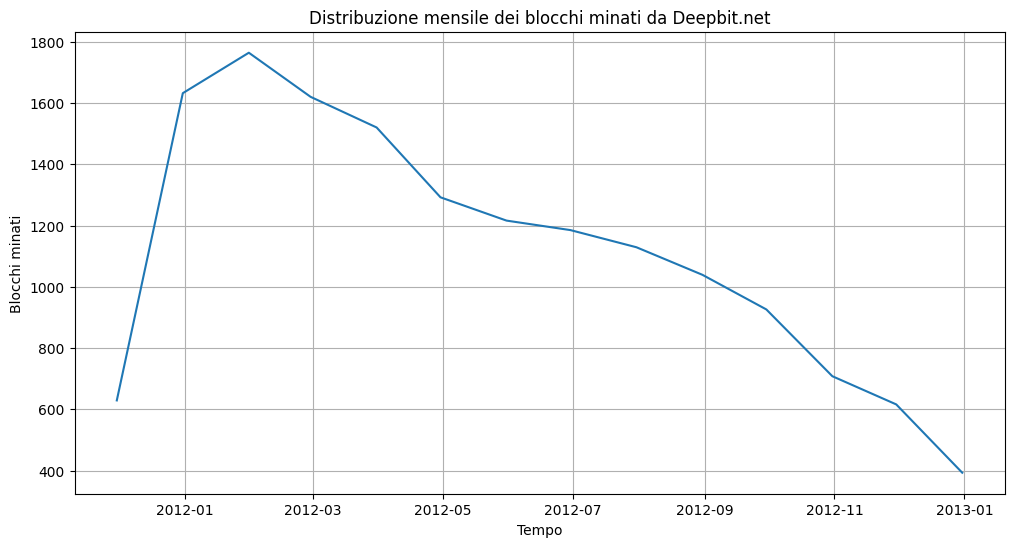

In [4]:
import matplotlib.pyplot as plt

# =========================================================
# DISTRIBUZIONE TEMPORALE DEI BLOCCHI MINATI DA DEEPBIT.NET
# =========================================================

# =========================================================
# 1. Costruzione DataFrame delle coinbase Deepbit
# =========================================================

deepbit_coinbase_df = transactions[transactions["txId"].isin(deepbit_coinbase_ids)].copy()

print("Coinbase Deepbit (df):", len(deepbit_coinbase_df))

# =========================================================
# 2. Conversione timestamp -> datetime
# =========================================================

deepbit_coinbase_df["datetime"] = pd.to_datetime(deepbit_coinbase_df["timestamp"], unit="s")
deepbit_coinbase_df = deepbit_coinbase_df.set_index("datetime")

# =========================================================
# 3. Resampling temporale (mensile)
# =========================================================

monthly_blocks = deepbit_coinbase_df.resample("ME").size() #resample serve a raggruppare i dati in base a un intervallo di tempo, in questo caso "ME" indica "Month End", cioè la fine del mese. La funzione size() conta il numero di occorrenze in ogni intervallo di tempo, quindi monthly_blocks conterrà il numero di blocchi minati da Deepbit.net per ogni mese.

# =========================================================
# 4. Visualizzazione grafica
# =========================================================

plt.figure(figsize=(12, 6))
plt.plot(monthly_blocks.index, monthly_blocks.values)
plt.xlabel("Tempo")
plt.ylabel("Blocchi minati")
plt.title("Distribuzione mensile dei blocchi minati da Deepbit.net")
plt.grid(True)
plt.show()

## Distribuzione delle fee ricevute da Deepbit.net

In questa parte vengono calcolate le fee effettivamente ricevute dalla mining pool Deepbit.net per ciascuna coinbase, in accordo con il protocollo Bitcoin.  
Per ogni coinbase associata a Deepbit viene identificato il blocco corrispondente e vengono selezionate tutte le transazioni incluse in tale blocco, escludendo la coinbase stessa.  

Le fee ricevute dal miner vengono quindi calcolate come la somma delle fee delle transazioni non coinbase del blocco, che rappresentano le commissioni pagate dagli utenti per l’inclusione delle loro transazioni.  
Tale valore viene infine associato alla coinbase e convertito da satoshi a bitcoin, ottenendo la fee totale incassata dalla mining pool per ciascun blocco minato.

Il grafico mostra la distribuzione cumulativa empirica (ECDF) delle fee ricevute dalla mining pool Deepbit.net per ciascun blocco minato.  
Per ogni valore sull’asse delle ascisse è rappresentata la frazione cumulativa di blocchi che hanno ricevuto una fee minore o uguale a tale valore.  
La curva evidenzia una forte concentrazione delle fee su valori molto bassi, con una crescita rapida della distribuzione per fee prossime allo zero e una coda lunga dovuta a pochi blocchi con fee più elevate.

Numero Coinbase Deepbit: 15669

Statistiche fee ricevute (BTC):


count    15669.000000
mean         0.054812
std          0.770086
min          0.000000
25%          0.003000
50%          0.017600
75%          0.046500
max         67.525000
Name: fee_btc, dtype: float64

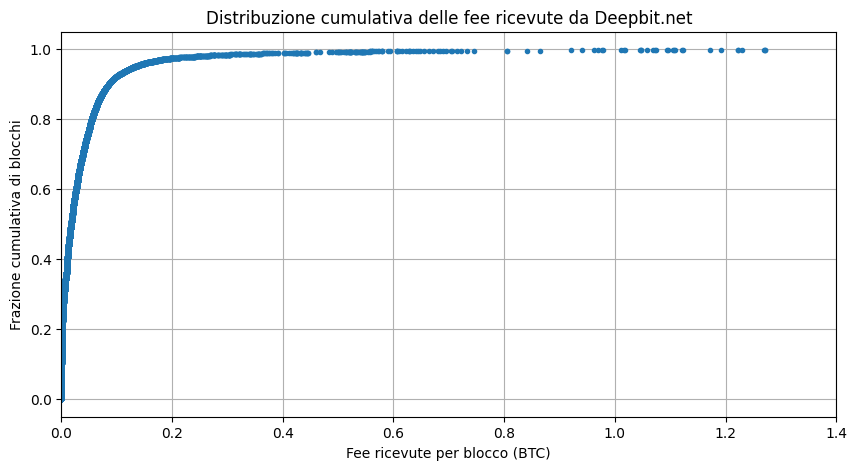

In [5]:
# =========================================================
# DISTRIBUZIONE DELLE FEE RICEVUTE DA DEEPBIT.NET
# =========================================================

# =========================================================
# 1. DataFrame delle coinbase Deepbit
# =========================================================

deepbit_coinbase_df = transactions[
    transactions["txId"].isin(deepbit_coinbase_ids)
][["txId", "blockId", "timestamp"]].copy()

print("Numero Coinbase Deepbit:", len(deepbit_coinbase_df))

# =========================================================
# 2. Calcolo delle fee ricevute per ogni coinbase
# =========================================================

# tutte le transazioni NON coinbase
non_coinbase_tx = transactions[transactions["isCoinbase"] == 0]

# somma delle fee per blocco
fees_per_block = (
    non_coinbase_tx 
    .groupby("blockId")["fee"] #vuol dire che raggruppa le transazioni per blockId e seleziona la colonna fee
    .sum()
)

# associamo le fee del blocco alle coinbase Deepbit
deepbit_coinbase_df["fee_satoshi"] = (
    deepbit_coinbase_df["blockId"]
    .map(fees_per_block) #map applica la somma delle fee per blocco alle coinbase Deepbit in base al blockId
    .fillna(0)
)

# conversione satoshi -> BTC
deepbit_coinbase_df["fee_btc"] = deepbit_coinbase_df["fee_satoshi"] / 1e8

# =========================================================
# 3. Statistiche descrittive delle fee ricevute
# =========================================================

print("\nStatistiche fee ricevute (BTC):")
display(deepbit_coinbase_df["fee_btc"].describe())

# =========================================================
# 4. Istogramma delle fee per coinbase
# =========================================================

import numpy as np

# valori delle fee per coinbase
fees = deepbit_coinbase_df["fee_btc"].values

# ECDF
x = np.sort(fees)
y = np.arange(1, len(x) + 1) / len(x) #frazione cumulativa, y = 1/N, 2/N, ..., N/N

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker=".", linestyle="none")
plt.xlim(0, 1.4)
plt.xlabel("Fee ricevute per blocco (BTC)")
plt.ylabel("Frazione cumulativa di blocchi")
plt.title("Distribuzione cumulativa delle fee ricevute da Deepbit.net")
plt.grid(True)
plt.show()

## Analisi degli UTXO associati a Deepbit.net

UTXO = output + tempo creazione + tempo spesa

In questa sezione viene effettuato il calcolo degli UTXO (Unspent Transaction Output) associati alla mining pool Deepbit.net, con l’obiettivo di analizzare l’andamento nel tempo del valore in bitcoin che risulta non speso.  
A partire da tutti gli output delle transazioni che trasferiscono fondi verso indirizzi appartenenti a Deepbit, vengono individuati gli output successivamente spesi e, per differenza, quelli che rimangono non spesi.  
Per ciascun UTXO vengono considerate sia la data di creazione sia, se presente, la data di spesa.  

Sulla base di tali informazioni viene costruita una serie temporale mensile che, per ogni mese del periodo considerato, rappresenta la somma complessiva degli importi non spesi alla fine del mese, includendo anche gli UTXO generati in mesi precedenti.  
L’andamento temporale ottenuto consente di osservare le fasi di accumulo e di spesa dei fondi da parte della mining pool.

Output totali verso Deepbit: 605393

UTXO Deepbit cumulativi (mensili):


2011-11-30     558.245042
2011-12-31    1061.283527
2012-01-31    3033.265439
2012-02-29     476.239623
2012-03-31    1806.274631
Freq: ME, dtype: float64

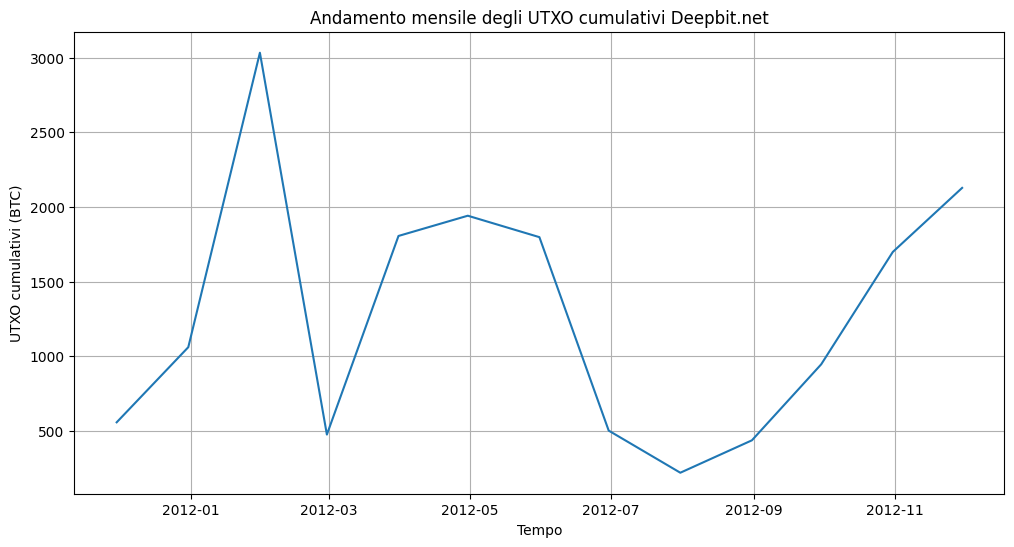

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CALCOLO DEGLI UTXO CUMULATIVI ASSOCIATI A DEEPBIT.NET
# =========================================================

# =========================================================
# 1. Tutti gli output verso Deepbit
# =========================================================

deepbit_outputs_all = outputs[
    outputs["address"].isin(deepbit_address_ids)
][["txId", "position", "amount"]].copy()

print("Output totali verso Deepbit:", len(deepbit_outputs_all))

# =========================================================
# 2. Individuazione output spesi (con timestamp di spesa)
# =========================================================

#join tra campo prevTxId e prevTxpos di inputs e txId e position di deepbit_outputs_all
spent_outputs = inputs.merge(deepbit_outputs_all, left_on=["prevTxId", "prevTxpos"], right_on=["txId", "position"], how="inner") #prendiamo solo gli UTXO di Deepbit che sono stati spesi

#timestamp della transazione che spende l'UTXO

#join tra campo txId_x di spent_outputs e campo txId di transactions
spent_outputs = spent_outputs.merge(transactions[["txId", "timestamp"]], left_on="txId_x", right_on="txId", how="left")
spent_outputs = spent_outputs.rename(columns={"timestamp": "spent_timestamp"})

# =========================================================
# 3. Creazione tabella UTXO con tempo di creazione e spesa
# =========================================================

#join tra campo txId di deepbit_outputs_all e campo txId di transactions
utxo = deepbit_outputs_all.merge(transactions[["txId", "timestamp"]], on="txId", how="left")
utxo = utxo.rename(columns={"timestamp": "created_timestamp"})

#join tra campo txId e position di utxo e campo txId_y e position di spent_outputs
utxo = utxo.merge(spent_outputs[["txId_y", "position", "spent_timestamp"]], left_on=["txId", "position"], right_on=["txId_y", "position"], how="left")
utxo = utxo.drop(columns=["txId_y"]) #rimuove la colonna txId_y ridondante

# =========================================================
# 4. Conversione timestamp -> datetime
# =========================================================

utxo["created_dt"] = pd.to_datetime(utxo["created_timestamp"], unit="s")
utxo["spent_dt"] = pd.to_datetime(utxo["spent_timestamp"], unit="s")

utxo["created_month"] = utxo["created_dt"].dt.to_period("M").dt.to_timestamp()
utxo["spent_month"] = utxo["spent_dt"].dt.to_period("M").dt.to_timestamp()

# =========================================================
# 5. Calcolo UTXO cumulativi a fine mese
# =========================================================

months = pd.date_range(     #date_range crea una serie di date mensili, crea una lista di date che vanno dal mese di creazione minimo degli UTXO al mese di creazione massimo degli UTXO, con frequenza mensile
    start=utxo["created_month"].min(),
    end=utxo["created_month"].max(),
    freq="ME"
)

utxo_per_month = []

for month in months:
    # UTXO creati entro il mese
    created_before = utxo["created_month"] <= month

    # UTXO non ancora spesi o spesi dopo il mese
    not_spent_yet = utxo["spent_month"].isna() #se e' NaN, cioe' non speso
    spent_after = utxo["spent_month"] > month

    alive = utxo[created_before & (not_spent_yet | spent_after)]  #filtra gli UTXO vivi a fine mese

    utxo_per_month.append(alive["amount"].sum() / 1e8)


monthly_utxo = pd.Series(utxo_per_month, index=months) #serie temporale degli UTXO cumulativi mensili

print("\nUTXO Deepbit cumulativi (mensili):")
display(monthly_utxo.head())

# =========================================================
# 6. Visualizzazione
# =========================================================

plt.figure(figsize=(12, 6))
plt.plot(monthly_utxo.index, monthly_utxo.values)
plt.xlabel("Tempo")
plt.ylabel("UTXO cumulativi (BTC)")
plt.title("Andamento mensile degli UTXO cumulativi Deepbit.net")
plt.grid(True)
plt.show()


## Catena di pagamenti associata a Deepbit.net

In questa sezione viene analizzata una catena di pagamenti riconducibile alla mining pool Deepbit.net, partendo da una transazione specifica. La catena viene costruita seguendo iterativamente gli output di tipo change, identificati come indirizzi appartenenti all’insieme Deepbit_addrs. La visita della catena prosegue esclusivamente nel caso in cui sia presente un solo change address, mentre viene interrotta se nessun output oppure più di un output appartiene a Deepbit.

Durante la costruzione della catena vengono inoltre raccolti in un insieme denominato OthersDeepbit gli indirizzi di output non appartenenti a Deepbit, che rappresentano i destinatari esterni dei trasferimenti di fondi. Per ciascuna coppia di transazioni consecutive della catena vengono quindi calcolate la differenza temporale tra i timestamp e la variazione dell’importo trasferito sul change address, al fine di analizzare l’evoluzione temporale e quantitativa dei pagamenti.

Infine, la catena di transazioni viene rappresentata tramite un grafo diretto costruito con NetworkX, che consente di visualizzare il flusso dei fondi e il pattern di transazioni adottato dalla mining pool per la gestione dei pagamenti e della privacy.

Transazione di partenza: 1883820


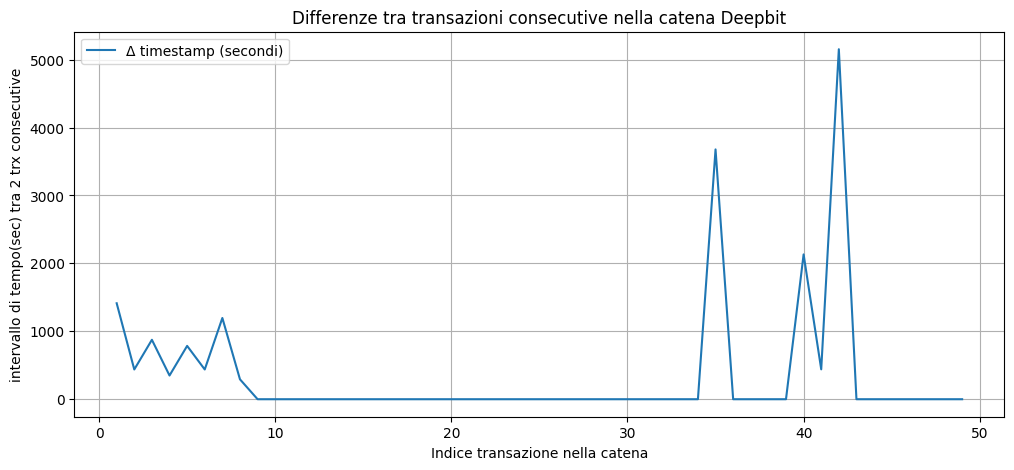

Un valore nullo dell’intervallo temporale indica che due transazioni consecutive della catena sono state incluse nello stesso blocco e condividono lo stesso timestamp.



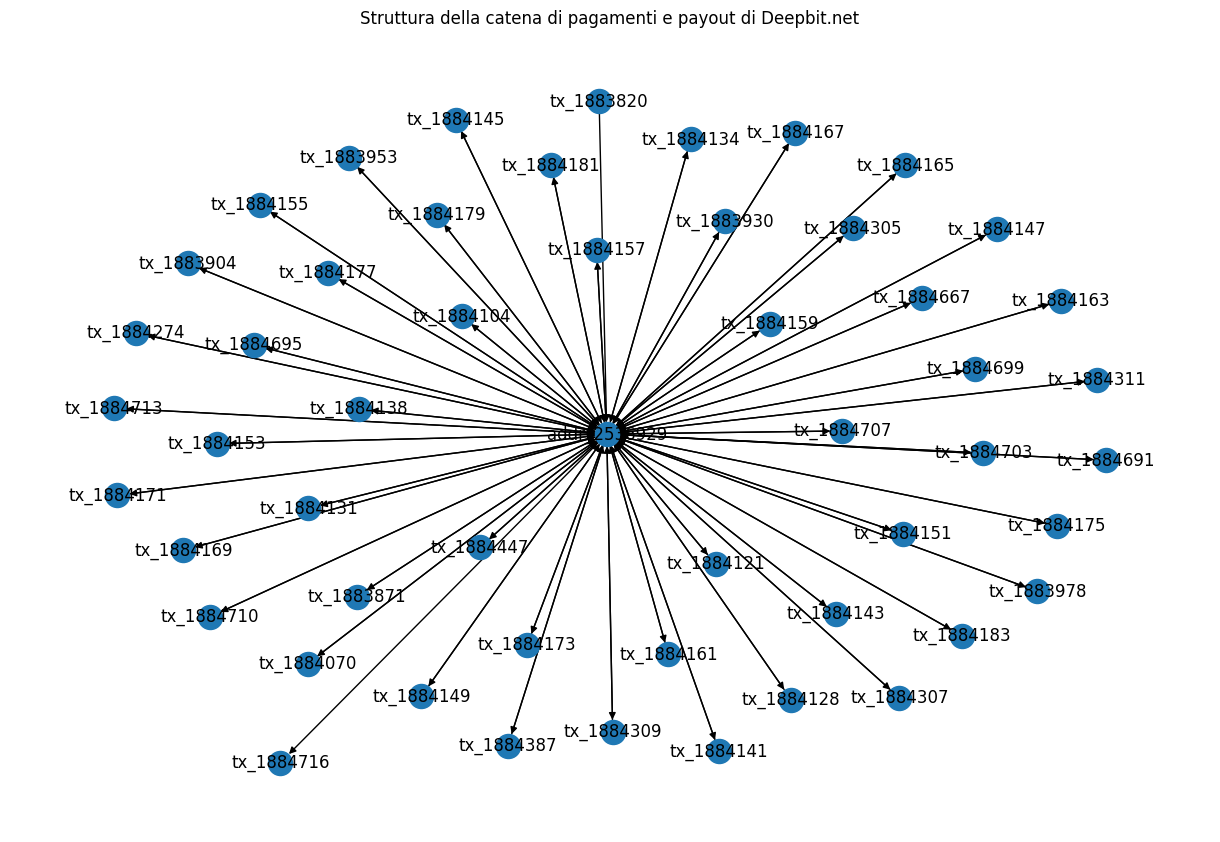

Numero nodi nel grafo: 52
Numero archi nel grafo: 100
Numero indirizzi in OthersDeepbit: 48

Il nodo centrale, fortemente connesso a molti nodi foglia, rappresenta una transazione di aggregazione o payout,
in cui Deepbit raccoglie fondi provenienti dalla catena dei change address e li redistribuisce verso più indirizzi esterni (OthersDeepbit),
tipicamente associati ai pagamenti ai miner.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# =========================================================
# CATENA DI PAGAMENTI ASSOCIATA A DEEPBIT.NET
# =========================================================

# =========================================================
# 1. Transazione di partenza (da consegna)
# =========================================================

start_tx = 1883820  # blocco 153932, timestamp 2011-11-19 07:39:30
print("Transazione di partenza:", start_tx)

# =========================================================
# 2. Inizializzazione strutture
# =========================================================

current_tx = start_tx
visited_tx = set()      #per tenere traccia delle transazioni già visitate

G = nx.DiGraph()        #grafo diretto per rappresentare la catena
OthersDeepbit = set()   #insieme di indirizzi esterni a Deepbit

# per memorizzare la catena (necessaria dopo)
chain = []  # (txId, timestamp, change_amount)

max_steps = 50
step = 0

# =========================================================
# 3. Costruzione della catena seguendo i change address
# =========================================================

while ( #finché ci sono transazioni da visitare
    current_tx is not None
    and current_tx not in visited_tx
    and step < max_steps
):
    visited_tx.add(current_tx)

    # timestamp transazione corrente
    ts = transactions.loc[
        transactions["txId"] == current_tx, "timestamp"
    ].iloc[0]   #prende il primo valore del timestamp della transazione corrente, iloc[0] seleziona il primo elemento della serie risultante

    # output della transazione corrente
    outs = outputs[outputs["txId"] == current_tx]
    if outs.empty: #se non ci sono output, esci dadal ciclo
        break

    # separazione output
    change_outputs = outs[outs["address"].isin(deepbit_address_ids)]    #output verso change address Deepbit, ovvero gli output che vanno a indirizzi Deepbit
    external_outputs = outs[~outs["address"].isin(deepbit_address_ids)] #output verso indirizzi esterni a Deepbit, il ~ serve per negare la condizione

    # aggiunta indirizzi esterni a OthersDeepbit
    for addr in external_outputs["address"].unique():
        OthersDeepbit.add(addr)

    # regola di prosecuzione: un solo change address
    if len(change_outputs) != 1:    #se non c'è esattamente un change address, esci dal ciclo
        break

    # output di change ovvero l'output che ritorna a Deepbit
    change_out = change_outputs.iloc[0]  #prende il primo (e unico) output di change
    change_addr = change_out["address"]  #indirizzo di change
    change_pos = change_out["position"]  #posizione dell'output di change
    change_amount = change_out["amount"] #quantità dell'output di change

    # salvataggio informazioni della catena
    chain.append((current_tx, ts, change_amount)) #catena in cui ogni elemento è una tupla (txId, timestamp, change_amount)

    # ricerca transazione successiva
    spend = inputs[
        (inputs["prevTxId"] == current_tx) &
        (inputs["prevTxpos"] == change_pos)
    ]

    if spend.empty:
        break

    next_tx = int(spend.iloc[0]["txId"]) #prende la prima transazione che spende l'output di change

    # passaggio alla transazione successiva
    current_tx = next_tx
    step += 1


# =========================================================
# 4. Costruzione del grafo della catena di pagamenti
# =========================================================

current_tx = start_tx
visited_tx.clear()
step = 0

while ( #finché ci sono transazioni da visitare
    current_tx is not None
    and current_tx not in visited_tx
    and step < len(chain)
):
    visited_tx.add(current_tx)
    G.add_node(f"tx_{current_tx}")  #aggiunge il nodo della transazione corrente, se esiste già non fa nulla

    outs = outputs[outputs["txId"] == current_tx] #outputs della transazione corrente

    #cerchiamo gli output (resto) che ritornano a Deepbit
    for _, out in outs.iterrows():  #cicla sugli output della transazione corrente, iterrows() restituisce indice e riga
        addr = out["address"] #addr contiene l'indirizzo del destinatario
        amount = out["amount"]
        pos = out["position"]

        G.add_node(f"addr_{addr}")  #crea il nodo dell'indirizzo del destinatario
        G.add_edge(f"tx_{current_tx}", f"addr_{addr}", amount=amount) #aggiunge l'arco dalla transazione all'indirizzo con l'attributo amount (quanto gli ha inviato)

        if addr in deepbit_address_ids: #se l'indirizzo è un change address Deepbit
            spend = inputs[ #spend contiene la transazione che spende questo output
                (inputs["prevTxId"] == current_tx) &
                (inputs["prevTxpos"] == pos)
            ]
            #se spend e' vuoto passa al prossimo output
            if not spend.empty: #se esiste una transazione che spende questo output
                next_tx = int(spend.iloc[0]["txId"]) #prende la prima transazione che spende l'output di change
                G.add_node(f"tx_{next_tx}")
                G.add_edge(f"addr_{addr}", f"tx_{next_tx}")
                current_tx = next_tx
                break #esce dal ciclo for per passare alla transazione successiva

    step += 1


# =========================================================
# 5. Calcolo delle differenze tra transazioni consecutive
# =========================================================

chain_df = pd.DataFrame(chain, columns=["txId", "timestamp", "change_amount"]) #crea un DataFrame dalla lista di tuple chain

chain_df["datetime"] = pd.to_datetime(chain_df["timestamp"], unit="s")  #converte il timestamp in formato datetime
chain_df["delta_time"] = chain_df["timestamp"].diff()                   #aggiunge una colonna delta_time che contiene la differenza tra il timestamp corrente e quello precedente,chain_df contiene [txId, timestamp, change_amount, datetime, delta_time]

# =========================================================
# 6. Visualizzazione delle differenze (grafico)
# =========================================================

plt.figure(figsize=(12, 5))
plt.plot(
    chain_df.index[1:], #salta il primo indice perché la differenza del primo elemento è NaN
    chain_df["delta_time"].iloc[1:],
    label="Δ timestamp (secondi)"
)

plt.xlabel("Indice transazione nella catena")
plt.ylabel("intervallo di tempo(sec) tra 2 trx consecutive")
plt.title("Differenze tra transazioni consecutive nella catena Deepbit")
plt.legend()
plt.grid(True)
plt.show()

print("Un valore nullo dell’intervallo temporale indica che due transazioni consecutive della catena sono state incluse nello stesso blocco e condividono lo stesso timestamp.\n")

# =========================================================
# 7. Visualizzazione del grafo della catena
# =========================================================

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=300, arrows=True)
plt.title("Struttura della catena di pagamenti e payout di Deepbit.net")
plt.show()

print("Numero nodi nel grafo:", G.number_of_nodes())
print("Numero archi nel grafo:", G.number_of_edges())
print("Numero indirizzi in OthersDeepbit:", len(OthersDeepbit))

print("\nIl nodo centrale, fortemente connesso a molti nodi foglia, rappresenta una transazione di aggregazione o payout,\nin cui Deepbit raccoglie fondi provenienti dalla " \
"catena dei change address e li redistribuisce verso più indirizzi esterni (OthersDeepbit),\ntipicamente associati ai pagamenti ai miner.")


In [8]:
# =========================================================
# Scraping per vedere quali indirizzi in OthersDeepbit sono deanonimizzati
# =========================================================

import requests
import time
from bs4 import BeautifulSoup

BASE_URL = "https://www.walletexplorer.com/address/"

results = []
max_requests = 5

# costruisci dizionario addressId -> hash (stringa indirizzo)
id_to_hash = mapping.set_index("addressId")["hash"].to_dict() #to dict converte la serie in un dizionario campi addressId e hash

print("numero di indirizzi in OthersDeepbit:", len(OthersDeepbit))
print("limite di richieste max impostato a:", max_requests)

for addr in OthersDeepbit:
    if len(results) >= max_requests: #per limitare il numero di richieste
        break
    addr_id = int(addr)  # può essere numpy.int64 -> cast a int
    addr_hash = id_to_hash.get(addr_id, None)

    # se non abbiamo l'hash (es. '0' o mancante) salta
    if not addr_hash or addr_hash == "0":
        results.append((addr_id, None, "No address hash"))
        continue

    url = BASE_URL + addr_hash
    #print("Controllo:", addr_id, "->", addr_hash)

    try:
        r = requests.get(url, timeout=10)
        if r.status_code != 200:
            results.append((addr_id, addr_hash, f"Errore HTTP: {r.status_code}"))
            continue

        soup = BeautifulSoup(r.text, "html.parser") #parsing HTML
        title_tag = soup.find("title")
        title = title_tag.get_text(strip=True) if title_tag else ""

        if "WalletExplorer" in title or "Address" in title or title == "":
            label = "Non deanonimizzato"
        else:
            label = title

        results.append((addr_id, addr_hash, label))

    except Exception as e:
        results.append((addr_id, addr_hash, f"Errore: {e}"))

    time.sleep(1) # evitiamo blocchi


df_others = pd.DataFrame(
    results,
    columns=["addressId", "hash", "label"]
)

display(df_others)



numero di indirizzi in OthersDeepbit: 48
limite di richieste max impostato a: 5


,addressId,hash,label
0,1000193,1NWBTs8LK7kJUDKe31uncF7nWpaUH14AMg,Non deanonimizzato
1,2155396,1J7UAz6yLqCnTELtrtMNbxhtwtMCaRhUTv,Non deanonimizzato
2,1389828,1HH72XEjqF5Nj596JbNevq3rN9kmcvZJKd,Non deanonimizzato
3,1334281,1DMEkfuP3bAuW6AbPg8jZ1vWU7485cVWjB,Non deanonimizzato
4,830089,1MbMktiA2kn5fy7HzwGoWW6eNHiN61QatG,Non deanonimizzato


## Analisi del servizio DiceOnCrack

In questa sezione vengono analizzate le transazioni associate al servizio di gambling DiceOnCrack, selezionando tutte quelle che presentano almeno un indirizzo di input o di output appartenente all’insieme DiceOnCrack_addrs. 
 Le transazioni vengono ordinate per block height e analizzate all’interno di un intervallo temporale del 2012.

Per ciascun blocco vengono individuati gruppi di transazioni inserite nello stesso blocco e vengono analizzati i cluster di dimensione maggiore o uguale a due, utilizzando gli indirizzi di input come proxy dei wallet.  
Per ogni blocco viene quindi calcolata e visualizzata la dimensione media dei cluster, evidenziando un pattern coerente con il comportamento tipico di un servizio di gambling, caratterizzato da raffiche di transazioni incluse simultaneamente nella blockchain.

Numero addressId DiceOnCrack: 27
Numero transazioni DiceOnCrack: 16702
Transazioni nell'intervallo: 724
Numero cluster: 177
Statistiche dimensione cluster:
count    177.000000
mean       4.090395
std        4.509179
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       28.000000
Name: txId, dtype: float64

Cluster (>=2 tx) e wallet unico:
Numero cluster validi: 15
Statistiche dimensione media cluster:
count    15.000000
mean      2.933333
std       0.798809
min       2.000000
25%       2.000000
50%       3.000000
75%       3.500000
max       4.000000
Name: cluster_size, dtype: float64


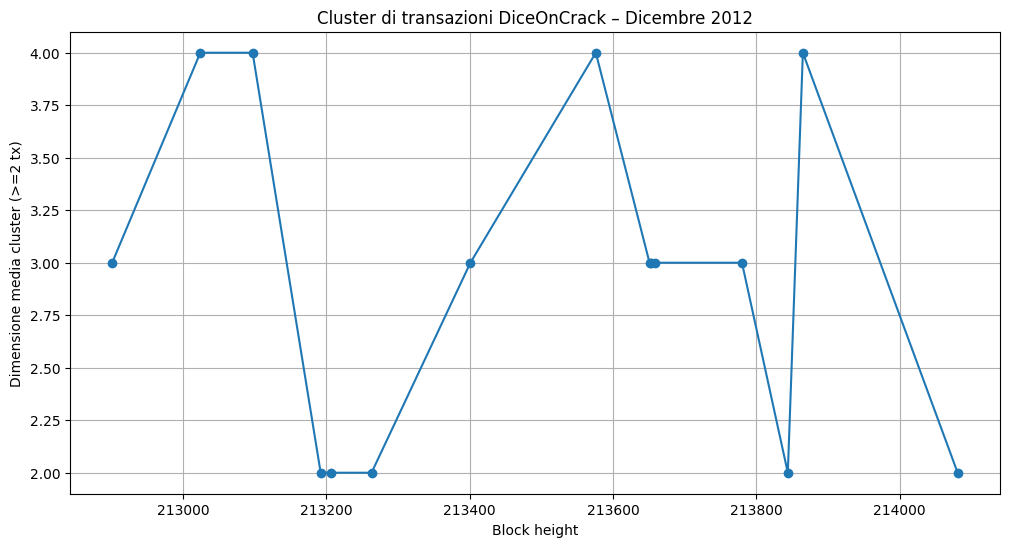

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# ANALISI DEL SERVIZIO DICEONCRACK
# =========================================================

# =========================================================
# 1. Caricamento indirizzi DiceOnCrack
# =========================================================

dice_addrs = pd.read_csv("diceoncrack_addrs.csv", header=None, names=["hash"])

#join tra campo hash di mapping e dice_addrs
dice_address_ids = mapping.merge(dice_addrs, on="hash", how="inner")["addressId"].unique()

print("Numero addressId DiceOnCrack:", len(dice_address_ids))

# =========================================================
# 2. Transazioni DiceOnCrack (INPUT o OUTPUT)
# =========================================================

# OUTPUT verso DiceOnCrack
dice_outputs = outputs[ #prendiamo gli output che hanno come destinatario un addressId di DiceOnCrack
    outputs["address"].isin(dice_address_ids)
][["txId", "position"]]

tx_out_dice = dice_outputs["txId"].unique() #identificativi delle transazioni che hanno output verso DiceOnCrack

# INPUT che spendono output DiceOnCrack
#join tra campo prevTxId e prevTxpos di inputs e txId, position di dice_outputs
dice_inputs = inputs.merge(dice_outputs, left_on=["prevTxId", "prevTxpos"], right_on=["txId", "position"], how="inner")
tx_in_dice = dice_inputs["txId_x"].unique()

# Unione tra tx_out_dice e tx_in_dice
dice_tx_ids = pd.Index(tx_out_dice).union(tx_in_dice) #l'unione ci da tutti gli identificativi delle transazioni che coinvolgono DiceOnCrack

print("Numero transazioni DiceOnCrack:", len(dice_tx_ids))

dice_transactions = transactions[ #filtra le transazioni che coinvolgono DiceOnCrack
    transactions["txId"].isin(dice_tx_ids)
][["txId", "blockId", "timestamp"]].copy()

# =========================================================
# 3. Selezione temporale (Dicembre 2012)
# =========================================================

dice_transactions["datetime"] = pd.to_datetime(dice_transactions["timestamp"], unit="s") 
dice_transactions = dice_transactions.sort_values("blockId") #ordina per blockId

mask = (    #filtro per date tra 20 e 30 dicembre 2012
    (dice_transactions["datetime"] >= "2012-12-20") &
    (dice_transactions["datetime"] <= "2012-12-30")
)

dice_window = dice_transactions[mask] #prendiamo solo le transazioni nell'intervallo di date specificato

print("Transazioni nell'intervallo:", len(dice_window))

# =========================================================
# 4. Insiemi di transazioni con stesso block height
# =========================================================

clusters = ( #raggruppa le transazioni per blockId, clusters conterra una serie in cui l'indice e' blockId e i valori sono liste di txId appartenenti a quel blockId
    dice_window
    .groupby("blockId")["txId"]
    .apply(list)
)

cluster_sizes = clusters.apply(len) #calcola la dimensione di ogni cluster, ovvero il numero di transazioni per ogni blockId

print("Numero cluster:", len(cluster_sizes))
print("Statistiche dimensione cluster:")
print(cluster_sizes.describe())

# =========================================================
# 5. FunzioneScraping WalletExplorer (address -> wallet)
# =========================================================

def scrape_wallet_name(address): #la funzione prende in input un indirizzo Bitcoin e restituisce il nome del wallet associato, se presente su WalletExplorer
    url = f"https://www.walletexplorer.com/address/{address}"
    try:
        r = requests.get(url, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        h2 = soup.find("h2")
        if h2:
            return h2.text.strip() #estrae il nome del wallet dall'intestazione h2
    except Exception:
        pass
    return None

# =========================================================
# 6. Identificazione cluster validi (wallet W unico)
# =========================================================

#join tra campo prevTxId e prevTxpos di inputs e campo txId e position di outputs per predere gli address degli input
inputs_with_addr = inputs.merge(outputs[["txId", "position", "address"]], left_on=["prevTxId", "prevTxpos"], right_on=["txId", "position"], how="left")
 
cluster_stats = []

for block_id, tx_ids in clusters.items(): #ogni cluster e' identificato dal block_id e contiene una lista di tx_ids
    #tx_ids contiene tutte le transazioni del cluster e' una lista 
    # cluster di dimensione >= 2
    if len(tx_ids) < 2: #non ci interessa cluster di dimensione 1 perche' e' una transazione isolata (non c'e' clustering qui)
        continue

    # indirizzi di input del cluster
    input_addrs = (inputs_with_addr #prendiamo gli indirizzi associati agli input delle transazioni nel cluster
        .loc[inputs_with_addr["txId_x"].isin(tx_ids), "address"]
        .dropna()   #rimuove valori NaN
        .unique()
    )

    if any(addr in dice_address_ids for addr in input_addrs): #se uno degli indirizzi di input appartiene a DiceOnCrack, salta questo cluster perche' vuol dire che e' interno a DiceOnCrack, l'obbiettivo e' trovare cluster esterni non associati a DiceOnCrack
        continue

    # scraping wallet
    wallet_names = set()
    for addr in input_addrs:
        wallet = scrape_wallet_name(addr)   #estrae il nome del wallet dall'indirizzo
        if wallet: #se il wallet e' stato trovato
            wallet_names.add(wallet)
        time.sleep(2)  # evita blocchi

    # cluster valido se wallet unico
    if len(wallet_names) == 1:
        cluster_stats.append({
            "blockId": block_id,
            "cluster_size": len(tx_ids),
            "wallet": list(wallet_names)[0]
        })


# =========================================================
# 7. Dimensione media dei cluster per blocco
# =========================================================

cluster_df = pd.DataFrame(cluster_stats)


print("\nCluster (>=2 tx) e wallet unico:")
print("Numero cluster validi:", len(cluster_df))

mean_cluster_size = (
    cluster_df
    .groupby("blockId")["cluster_size"]
    .mean()
)

print("Statistiche dimensione media cluster:")
print(mean_cluster_size.describe())

# =========================================================
# 8. Visualizzazione grafica
# =========================================================

plt.figure(figsize=(12,6))
plt.plot(
    mean_cluster_size.index,
    mean_cluster_size.values,
    marker="o",
    linestyle="-"
)
plt.xlabel("Block height")
plt.ylabel("Dimensione media cluster (>=2 tx)")
plt.title("Cluster di transazioni DiceOnCrack – Dicembre 2012")
plt.grid(True)
plt.show()


Il pattern osservato è compatibile con un comportamento tipico di un gambler in cui gli utenti inviano più puntate in rapida successione.  
Le transazioni vengono aggregate e incluse nello stesso blocco, producendo cluster di dimensione maggiore di uno con input riconducibili allo stesso wallet.